# Analytics Final Project on Movie Ratings

## Question and background information

**Question:** What factors are most predictive of a movie achieving a "high" audience rating (an IMDb score of 7.0 or greater), and can we accurately classify a film's critical reception based on its pre-release characteristics (like budget, genre, MPAA rating) and post-release engagement (like runtime and user votes)?

**Background:** The movie field is highly competitive, and understanding what drives audience satisfaction is really valuable for studios, directors, and investors. While blockbusters with massive budgets frequently dominate the box office, they don't necessarily secure the highest audience ratings. Conversely, lower-budget films or specific genres might consistently resonate better with viewers. Our analysis uses a movie dataset released from 1980 to 2020 to explore these dynamics. The dataset contains a mixture of both categorical inputs such as the movie's genre, primary star, director, and the production company as well as numerical inputs like the production budget, total votes, and movie runtime.

By categorizing our target variable into a binary classification (where a movie is considered 'high-rated' if it scores a 7.0 or above), we simplify the problem to focus on the key separators of acclaimed films versus average or poorly-received films. Finally, exploring this dataset through predictive modeling will allow us to uncover whether artistic choices (like genre or runtime) or financial resources (budget and cast) are the truest indicators of audience approval.


## Import Packages

In [231]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

## Load Data and Get Basic Dataset Stats

In [232]:
# Load movie dataset
df = pd.read_csv("movies_dataset.csv")

# Preview the dataset
print(df.head())

                                             name rating      genre  year  \
0                                     The Shining      R      Drama  1980   
1                                 The Blue Lagoon      R  Adventure  1980   
2  Star Wars: Episode V - The Empire Strikes Back     PG     Action  1980   
3                                       Airplane!     PG     Comedy  1980   
4                                      Caddyshack      R     Comedy  1980   

                        released  score      votes         director  \
0  June 13, 1980 (United States)    8.4   927000.0  Stanley Kubrick   
1   July 2, 1980 (United States)    5.8    65000.0   Randal Kleiser   
2  June 20, 1980 (United States)    8.7  1200000.0   Irvin Kershner   
3   July 2, 1980 (United States)    7.7   221000.0     Jim Abrahams   
4  July 25, 1980 (United States)    7.3   108000.0     Harold Ramis   

                    writer            star         country      budget  \
0             Stephen King  Jack Nic

In [233]:
# Print the columns and shape of the dataset
print(df.info(), "\n")
print("\nUpdated shape:", df.shape)

<class 'pandas.DataFrame'>
RangeIndex: 7668 entries, 0 to 7667
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      7668 non-null   str    
 1   rating    7591 non-null   str    
 2   genre     7668 non-null   str    
 3   year      7668 non-null   int64  
 4   released  7666 non-null   str    
 5   score     7665 non-null   float64
 6   votes     7665 non-null   float64
 7   director  7668 non-null   str    
 8   writer    7665 non-null   str    
 9   star      7667 non-null   str    
 10  country   7665 non-null   str    
 11  budget    5497 non-null   float64
 12  gross     7479 non-null   float64
 13  company   7651 non-null   str    
 14  runtime   7664 non-null   float64
dtypes: float64(5), int64(1), str(9)
memory usage: 898.7 KB
None 


Updated shape: (7668, 15)


In [234]:
print(df.describe())

              year        score         votes        budget         gross  \
count  7668.000000  7665.000000  7.665000e+03  5.497000e+03  7.479000e+03   
mean   2000.405451     6.390411  8.810850e+04  3.558988e+07  7.850054e+07   
std      11.153508     0.968842  1.633238e+05  4.145730e+07  1.657251e+08   
min    1980.000000     1.900000  7.000000e+00  3.000000e+03  3.090000e+02   
25%    1991.000000     5.800000  9.100000e+03  1.000000e+07  4.532056e+06   
50%    2000.000000     6.500000  3.300000e+04  2.050000e+07  2.020576e+07   
75%    2010.000000     7.100000  9.300000e+04  4.500000e+07  7.601669e+07   
max    2020.000000     9.300000  2.400000e+06  3.560000e+08  2.847246e+09   

           runtime  
count  7664.000000  
mean    107.261613  
std      18.581247  
min      55.000000  
25%      95.000000  
50%     104.000000  
75%     116.000000  
max     366.000000  


In [235]:
# Create a copy so we don't modify the original dataframe
movies = df.copy()

In [236]:
# Remove rows where the movie score is missing
movies = movies.dropna(subset=["score"])

# Create binary target:
# 1 = high-rated movie (score >= 7), 0 = lower-rated
movies["high_rating"] = (movies["score"] >= 7).astype(int)

# Check distribution of the target variable
print(movies["high_rating"].value_counts())
print()
print(movies["high_rating"].value_counts(normalize=True))

high_rating
0    5399
1    2266
Name: count, dtype: int64

high_rating
0    0.704371
1    0.295629
Name: proportion, dtype: float64


In [237]:
# Remove duplicate rows to avoid bias in training
movies = movies.drop_duplicates()

# Check missing values in each column
print(movies.isnull().sum())

name              0
rating           75
genre             0
year              0
released          2
score             0
votes             0
director          0
writer            3
star              1
country           3
budget         2171
gross           186
company          15
runtime           4
high_rating       0
dtype: int64


In [238]:
# Drop rows with missing values in selected columns
movies = movies.dropna(subset=[
    "rating",
    "writer",
    "star",
    "country",
    "company",
    "runtime",
    "budget",
    "gross"
])

## Conduct EDA

In [239]:
# Check remaining missing values
print(movies.info())

# Print updated shape to see how many rows remain
print("\nUpdated shape:", movies.shape)

<class 'pandas.DataFrame'>
Index: 5421 entries, 0 to 7652
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   name         5421 non-null   str    
 1   rating       5421 non-null   str    
 2   genre        5421 non-null   str    
 3   year         5421 non-null   int64  
 4   released     5421 non-null   str    
 5   score        5421 non-null   float64
 6   votes        5421 non-null   float64
 7   director     5421 non-null   str    
 8   writer       5421 non-null   str    
 9   star         5421 non-null   str    
 10  country      5421 non-null   str    
 11  budget       5421 non-null   float64
 12  gross        5421 non-null   float64
 13  company      5421 non-null   str    
 14  runtime      5421 non-null   float64
 15  high_rating  5421 non-null   int64  
dtypes: float64(5), int64(2), str(9)
memory usage: 720.0 KB
None

Updated shape: (5421, 16)


In [240]:
# Summary statistics for key numeric variables
print(movies.describe())

              year        score         votes        budget         gross  \
count  5421.000000  5421.000000  5.421000e+03  5.421000e+03  5.421000e+03   
mean   2001.661317     6.392455  1.150661e+05  3.600917e+07  1.032297e+08   
std      10.540908     0.962730  1.844073e+05  4.157337e+07  1.873027e+08   
min    1980.000000     1.900000  1.950000e+02  6.000000e+03  3.090000e+02   
25%    1993.000000     5.800000  1.900000e+04  1.000000e+07  1.073640e+07   
50%    2002.000000     6.500000  5.200000e+04  2.180000e+07  3.686941e+07   
75%    2011.000000     7.100000  1.290000e+05  4.500000e+07  1.124625e+08   
max    2020.000000     9.300000  2.400000e+06  3.560000e+08  2.847246e+09   

           runtime  high_rating  
count  5421.000000  5421.000000  
mean    108.152739     0.289246  
std      18.115698     0.453454  
min      63.000000     0.000000  
25%      95.000000     0.000000  
50%     105.000000     0.000000  
75%     118.000000     1.000000  
max     271.000000     1.000000  


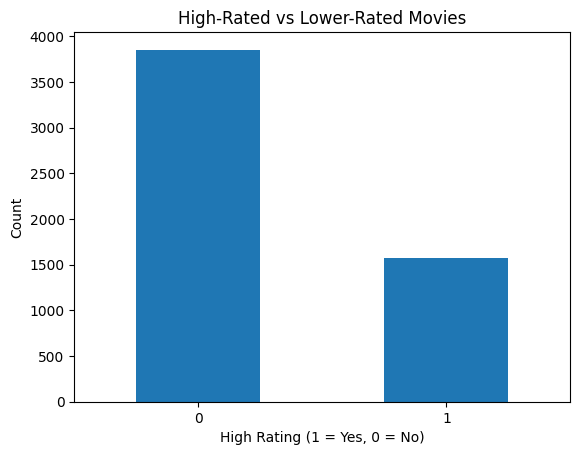

In [241]:
# Visualize how many movies are high-rated vs lower-rated
movies["high_rating"].value_counts().plot(kind="bar")
plt.title("High-Rated vs Lower-Rated Movies")
plt.xlabel("High Rating (1 = Yes, 0 = No)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

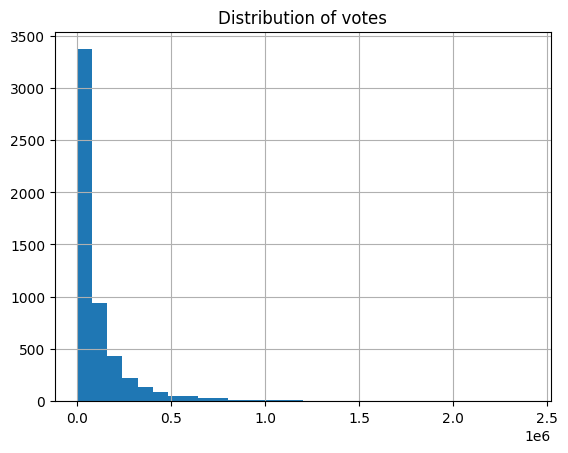

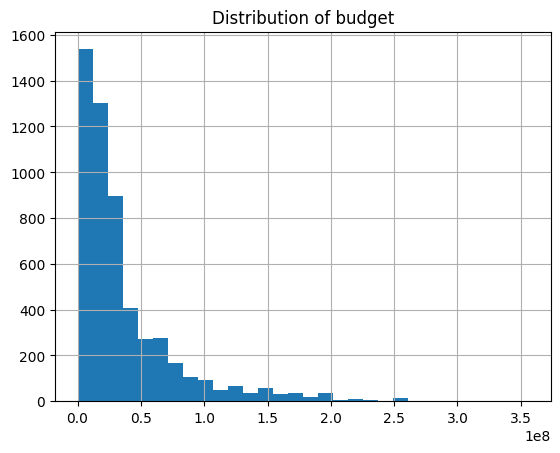

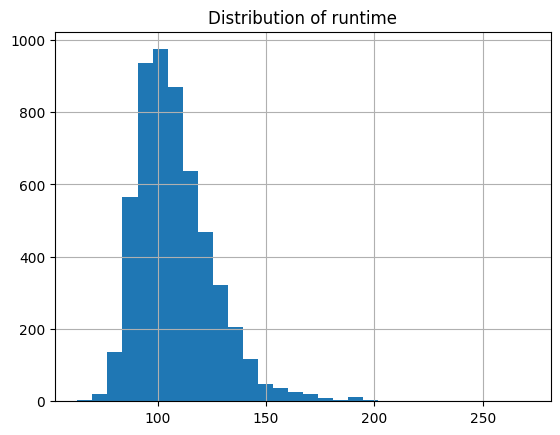

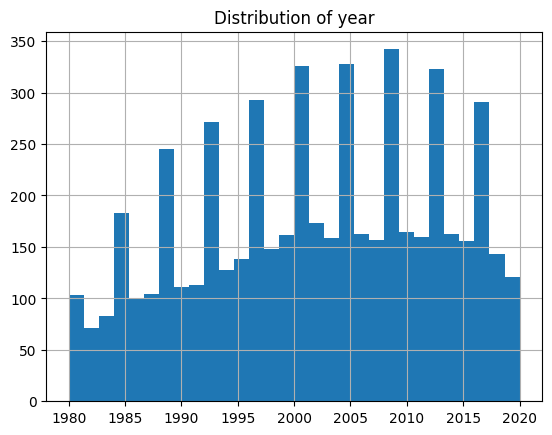

In [242]:
# Plot distributions of important numeric variables
for col in ["votes", "budget", "runtime", "year"]:
    movies[col].hist(bins=30)
    plt.title(f"Distribution of {col}")
    plt.show()

In [243]:
# Compare average values of features between classes
for col in ["votes", "budget", "runtime", "year"]:
    print(f"\nAverage {col} by high_rating:")
    print(movies.groupby("high_rating")[col].mean())


Average votes by high_rating:
high_rating
0     65506.581884
1    236847.338010
Name: votes, dtype: float64

Average budget by high_rating:
high_rating
0    3.518441e+07
1    3.803582e+07
Name: budget, dtype: float64

Average runtime by high_rating:
high_rating
0    104.291461
1    117.640944
Name: runtime, dtype: float64

Average year by high_rating:
high_rating
0    2001.391124
1    2002.325255
Name: year, dtype: float64


In [244]:
# Show most common genres
print("Top genres:")
print(movies["genre"].value_counts().head(10))

Top genres:
genre
Comedy       1496
Action       1415
Drama         863
Crime         399
Adventure     327
Biography     311
Animation     277
Horror        251
Fantasy        41
Mystery        17
Name: count, dtype: int64


**EDA Insights**: 
Based on the visualizations above, we can identify several relationships that are critical for our analysis. Higher-rated movies tend to receive significantly more votes and have longer runtimes than their lower-rated counterparts. Budget distributions also show some variations, suggesting these numerical factors play a key role in movie reception. Furthermore, certain genres (like Drama, Action, and Comedy) dominate the dataset, highlighting important categorical predictors. Together, these initial statistics inform our choice of features for predicting movie ratings.

## Feature Selection

In [245]:
# Select reasonable set of features for prediction
# These include both numeric and categorical variables
features = [
    "rating",    # MPAA rating (PG, R, etc.)
    "genre",
    "year",
    "votes",
    "director",
    "star",
    "country",
    "budget",
    "company",
    "runtime"
]

# Define input features (X) and target (y)
X = movies[features]
y = movies["high_rating"]

# Print selected features
print("Features being used:")
print(features)

Features being used:
['rating', 'genre', 'year', 'votes', 'director', 'star', 'country', 'budget', 'company', 'runtime']


## Train/Test Split

In [246]:
# Split data into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y  # keeps class balance consistent
)

print(X_train.shape)
print(X_test.shape)

(4336, 10)
(1085, 10)


## Preprocessing Pipeline

In [247]:
# Identify numeric and categorical columns automatically
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "string"]
).columns.tolist()

# Since missing values were already removed during cleaning,
# numeric columns can pass through unchanged.
# Categorical columns need one-hot encoding for the model.
preprocessor = ColumnTransformer([
    ("num", "passthrough", numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

# Print feature groups for verification
print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['year', 'votes', 'budget', 'runtime']

Categorical features:
['rating', 'genre', 'director', 'star', 'country', 'company']


## Methods & Evaluation

### Model 1: Decision Tree

#### Training/Tuning Phase

In [248]:
# Create a pipeline with preprocessing + Decision Tree model
dt_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(max_depth=3, random_state=42))
])

# Train the model on the training data
dt_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [249]:
from sklearn.tree import export_text

# Extract the trained classifier from the pipeline
dt_clf = dt_model.named_steps["classifier"]

# Get feature names after preprocessing
feature_names = dt_model.named_steps["preprocessor"].get_feature_names_out()

# Print the decision tree rules
tree_rules = export_text(dt_clf, feature_names=list(feature_names))
print(tree_rules)

|--- num__votes <= 230500.00
|   |--- num__runtime <= 119.50
|   |   |--- num__votes <= 79500.00
|   |   |   |--- class: 0
|   |   |--- num__votes >  79500.00
|   |   |   |--- class: 0
|   |--- num__runtime >  119.50
|   |   |--- num__budget <= 44500000.00
|   |   |   |--- class: 1
|   |   |--- num__budget >  44500000.00
|   |   |   |--- class: 0
|--- num__votes >  230500.00
|   |--- num__votes <= 492500.00
|   |   |--- num__budget <= 65500000.00
|   |   |   |--- class: 1
|   |   |--- num__budget >  65500000.00
|   |   |   |--- class: 0
|   |--- num__votes >  492500.00
|   |   |--- cat__director_George Lucas <= 0.50
|   |   |   |--- class: 1
|   |   |--- cat__director_George Lucas >  0.50
|   |   |   |--- class: 0



#### Evaluation of model 1

In [250]:
# Generate predictions on test data
dt_pred = dt_model.predict(X_test)

# Print performance metrics
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print("\nDecision Tree Classification Report:")
print(classification_report(y_test, dt_pred))

Decision Tree Accuracy: 0.7714285714285715

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.91      0.85       771
           1       0.66      0.44      0.53       314

    accuracy                           0.77      1085
   macro avg       0.73      0.67      0.69      1085
weighted avg       0.76      0.77      0.76      1085



In [251]:
# Interpretation of results
print("Decision Tree Interpretation:")
print("This model is simple and interpretable, but may not capture complex relationships in the data.")

Decision Tree Interpretation:
This model is simple and interpretable, but may not capture complex relationships in the data.


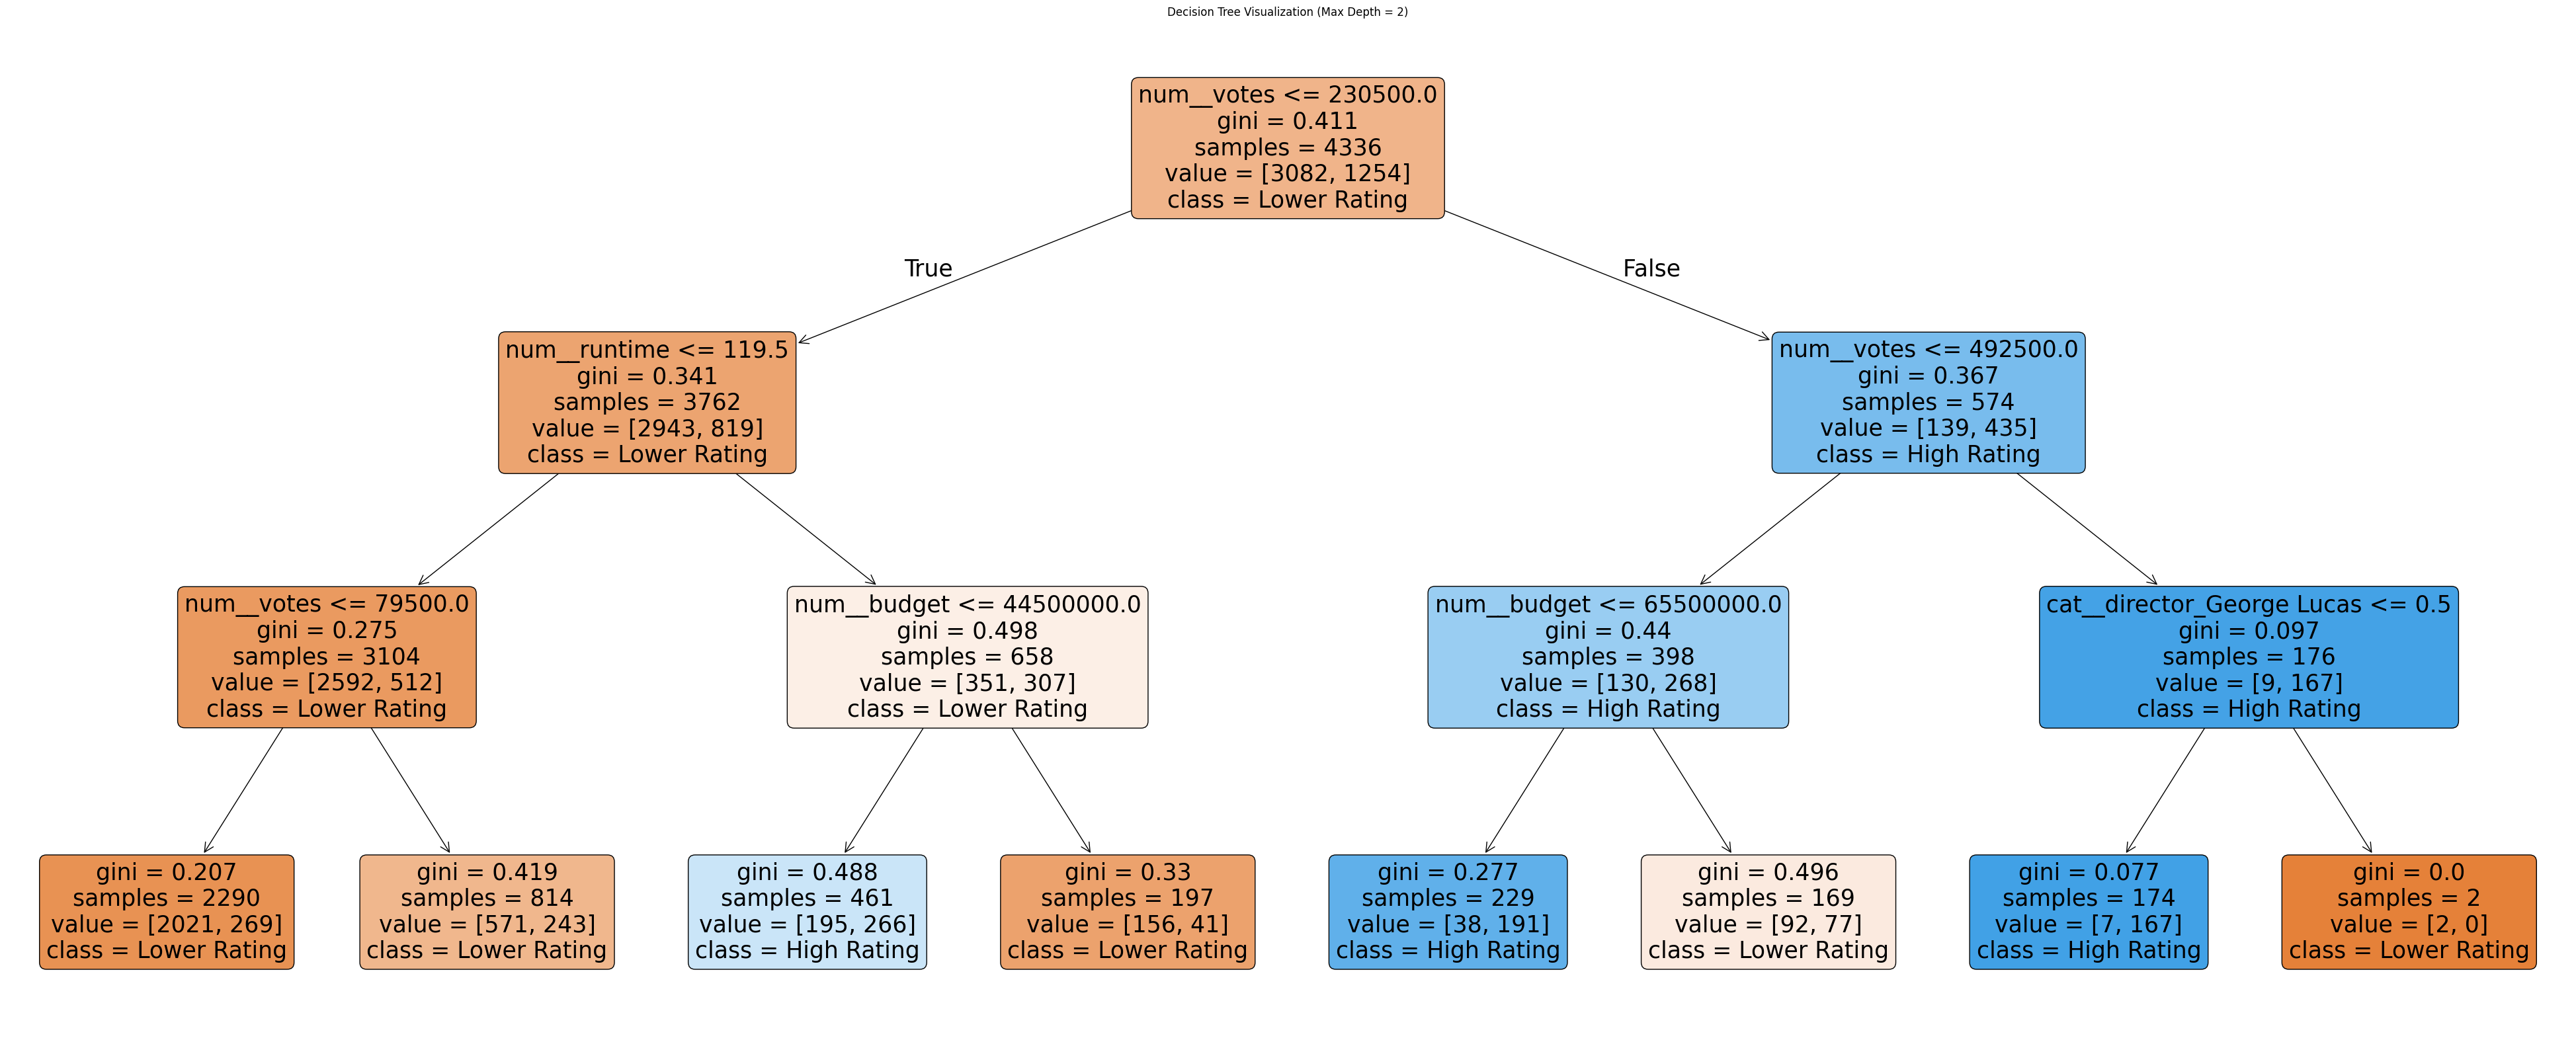

In [252]:
from sklearn.tree import plot_tree

plt.figure(figsize=(50, 20))

# Extract classifier and feature names
dt_clf = dt_model.named_steps["classifier"]
feature_names = dt_model.named_steps["preprocessor"].get_feature_names_out()

# Plot tree
plot_tree(
    dt_clf,
    feature_names=list(feature_names),
    class_names=['Lower Rating', 'High Rating'],
    filled=True,
    rounded=True,
    fontsize=25,
    max_depth=3  # reduced depth to improve readability and remove clutter
)

plt.title("Decision Tree Visualization (Max Depth = 2)")
plt.savefig('final_decision_tree_viz.png', bbox_inches='tight')
plt.show()

### Model 2: Random Forest

#### Training/Tuning Phase

In [253]:
# Pipeline with random forest model
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,  # number of trees
        max_depth=10,      # limit depth to reduce overfitting
        random_state=42
    ))
])

# Train model
rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

#### Evaluation of model 2

In [254]:
# Predict using Random Forest
rf_pred = rf_model.predict(X_test)

# Print evaluation metrics
print("Random forest accuracy:", accuracy_score(y_test, rf_pred))
print("\nRandom forest classification report:")
print(classification_report(y_test, rf_pred))

Random forest accuracy: 0.7115207373271889

Random forest classification report:
              precision    recall  f1-score   support

           0       0.71      1.00      0.83       771
           1       1.00      0.00      0.01       314

    accuracy                           0.71      1085
   macro avg       0.86      0.50      0.42      1085
weighted avg       0.79      0.71      0.59      1085



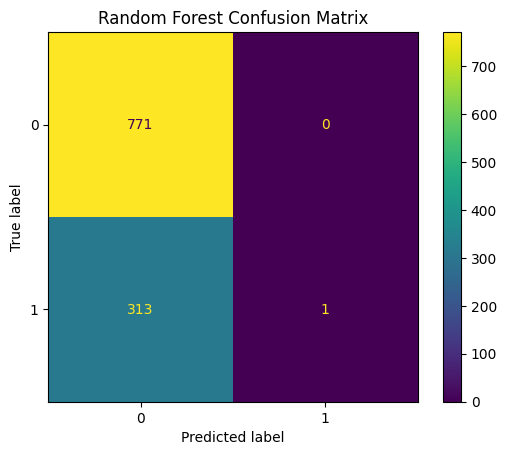

In [255]:
# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, rf_pred)
plt.title("Random Forest Confusion Matrix")
plt.show()

In [256]:
# Interpretation of results
print("Random Forest Interpretation:")
print("This model combines multiple trees, improving accuracy and reducing overfitting.")

Random Forest Interpretation:
This model combines multiple trees, improving accuracy and reducing overfitting.


### Model 3: Logistic Regression

#### Training/Tuning Phase

In [257]:
from sklearn.linear_model import LogisticRegression

# Create pipeline with Logistic Regression model
lr_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

# Train the Logistic Regression model
lr_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

#### Evaluation of model 3

In [258]:
# Predict using Logistic Regression
lr_pred = lr_model.predict(X_test)

# Print evaluation metrics
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print("\nLogistic Regression Classification Report:")
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.8129032258064516

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.94      0.88       771
           1       0.78      0.49      0.60       314

    accuracy                           0.81      1085
   macro avg       0.80      0.72      0.74      1085
weighted avg       0.81      0.81      0.80      1085



## Model Comparison

In [259]:
# Compare model performance using accuracy
results = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest", "Logistic Regression"],
    "Accuracy": [
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, lr_pred)
    ]
})

print(results)

                 Model  Accuracy
0        Decision Tree  0.771429
1        Random Forest  0.711521
2  Logistic Regression  0.812903


In [260]:
# Compare model performance using accuracy
results = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest", "Logistic Regression"],
    "Accuracy": [
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, lr_pred)
    ]
})

print(results)

                 Model  Accuracy
0        Decision Tree  0.771429
1        Random Forest  0.711521
2  Logistic Regression  0.812903


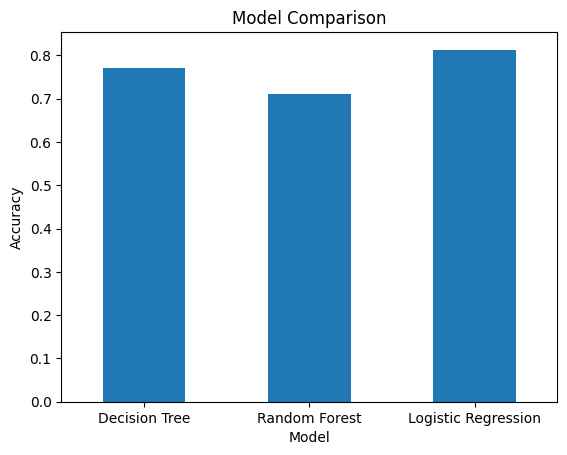

In [261]:
# Visual comparison of model accuracy
results.plot(x="Model", y="Accuracy", kind="bar", legend=False)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=0)
plt.show()

In [262]:
# Identify best model
best_model = results.loc[results["Accuracy"].idxmax(), "Model"]
best_accuracy = results["Accuracy"].max()

print(f"The better model was {best_model} with accuracy {best_accuracy:.4f}.")

The better model was Logistic Regression with accuracy 0.8129.


In [263]:
# Extract trained Random Forest model
rf_clf = rf_model.named_steps["classifier"]

# Get feature names after preprocessing
feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()

# Create DataFrame of feature importance scores
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_clf.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importance_df.head(10))

                         Feature  Importance
1                     num__votes    0.152124
3                   num__runtime    0.094451
15          cat__genre_Biography    0.035826
16             cat__genre_Comedy    0.030905
18              cat__genre_Drama    0.021727
2                    num__budget    0.021573
3547  cat__country_United States    0.019881
21             cat__genre_Horror    0.016389
0                      num__year    0.014448
12             cat__genre_Action    0.013954


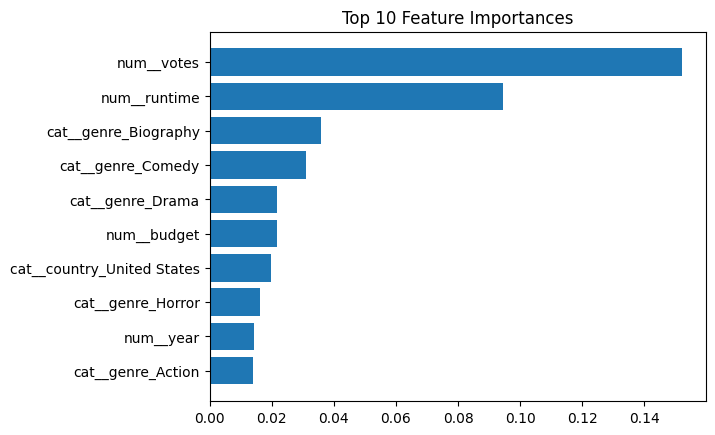

In [264]:
# Plot top 10 most important features
top = importance_df.head(10).sort_values(by="Importance")

plt.barh(top["Feature"], top["Importance"])
plt.title("Top 10 Feature Importances")
plt.show()

## Model Comparison Summary

We tested three classification models to answer our research question: Decision Tree, Random Forest, and Logistic Regression. While each model had strengths, Logistic Regression performed the best overall based on accuracy and balanced classification performance.

The Decision Tree model achieved an accuracy of 77.1% and was highly interpretable because its predictions could be visualized through simple decision rules. However, its recall for high-rated movies (class 1) was only 0.44, meaning it missed many movies that were actually highly rated. Random Forest performed the worst in this case, with an accuracy of 71.2%, and it almost completely failed to identify high-rated movies, with a class 1 recall of 0.00. This suggests the model was over-predicting the majority class (lower-rated movies) and was not useful for our specific goal.

Logistic Regression achieved the highest overall accuracy at 81.3%, along with the strongest balance between precision, recall, and F1-score for the high-rated movie class. Its class 1 precision was 0.78, recall was 0.49, and F1-score was 0.60, all of which were better than the Decision Tree and significantly better than Random Forest. This means Logistic Regression was more reliable at correctly identifying highly rated movies while also maintaining strong overall prediction accuracy.

Because of this balance between performance and explainability, Logistic Regression was selected as the best final model for this project. It provided the strongest overall predictive results while remaining relatively simple to interpret and explain.

## Conclusion

The goal of this project was to answer the question: Can we predict whether a movie will receive a high rating based on features such as genre, votes, budget, runtime, year, and other production related characteristics? Based on our results, the answer is yes. Machine learning models can reasonably predict whether a movie is likely to be highly rated, although the predictions are not perfect and should be viewed as estimates rather than guarantees.

After cleaning the dataset, conducting exploratory data analysis, and testing multiple classification models, we found that several variables showed meaningful relationships with movie ratings. High-rated movies generally had more audience votes, slightly larger budgets, and longer runtimes. Certain genres also appeared more frequently among highly rated films. These patterns supported the idea that both production factors and audience engagement contribute to movie success.

We compared three models: Decision Tree, Random Forest, and Logistic Regression. Logistic Regression was selected as the best final model because it produced the highest overall accuracy (81.3%) while also maintaining the strongest balance between precision, recall, and F1 score for predicting high rated movies. Although decision tree was easier to visualize and explain, it missed too many high rated movies, and Random Forest performed poorly in this case by overpredicting lower-rated films. Logistic Regression provided the most practical balance between predictive performance and interpretability.

However, there are important limitations to our model. First, the dataset does not include major factors such as critic reviews, marketing spend, streaming popularity, franchise strength, awards, or social media influence, all of which can strongly affect movie ratings. Second, using a threshold of 7 to define a “high-rated” movie simplifies movie quality into only two categories and removes some nuance from the original score variable. Additionally, variables such as director, writer, and star were treated only as categorical labels rather than by measuring reputation or prior success, which may limit predictive power.

Another limitation is that the models only use structured numeric and categorical data and do not account for unstructured information such as plot quality, screenplay strength, reviews, or audience sentiment. These types of variables are often difficult to measure but may be some of the strongest drivers of movie ratings. Because of this, even the best-performing model cannot fully explain why a movie succeeds.

Overall, this project demonstrates that data science can provide meaningful insight into movie ratings and help identify patterns associated with stronger performing films. Logistic regression proved to be the strongest final model for this dataset, but future improvements could include more advanced feature engineering, additional real world variables, and stronger handling of movie quality beyond simple numeric thresholds.

## Team contribution

Summary of the various contributions of individual team members:

- **Data Engineer**: Michelle and William
- **Researcher**: Nelson
- **Model Builder**: Michelle and William
- **Red Team / Final Reviewer**: Michelle, Nelson, William

To be more specific, Nelson created the README and conducted research on our topic. After he gave us a lot of options to explore, we decided as a collective to analyze a movies dataset to which Nelson found. William and Michelle contributed a lot to writing the code. William primarily did the data cleaning and also helped with model creation, while Michelle added parts as required by the rubric that weren't previously present. She also handled the pushes to Github since we wanted a clean commit log. While we acknowledge that it's usually best to have everyone push their own changes when needed, due to our frequent meetings in person, we were able to compare code in person and figure out what changes from each person were best, so we didn't have conflicting code. Lastly, Michelle did the Question and Background Information, William wrote the Conclusions, and we all contributed to writing the Team Contribution portion and conducting the final review.